**Modeling context-dependent decision-making by reproducing Mante and Sussillo, 2013** (https://www.nature.com/articles/nature12742)

Full reference:
Mante V, Sussillo D, Shenoy KV, Newsome WT. Context-dependent computation by recurrent dynamics in prefrontal cortex.
Nature. 2013 Nov 7;503(7474):78-84. doi: 10.1038/nature12742. PMID: 24201281; PMCID: PMC4121670.

In [ ]:
#import a bunch of libraries (some will be useful later on)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression
from numpy.linalg import qr

**Section A: Create a dataset**




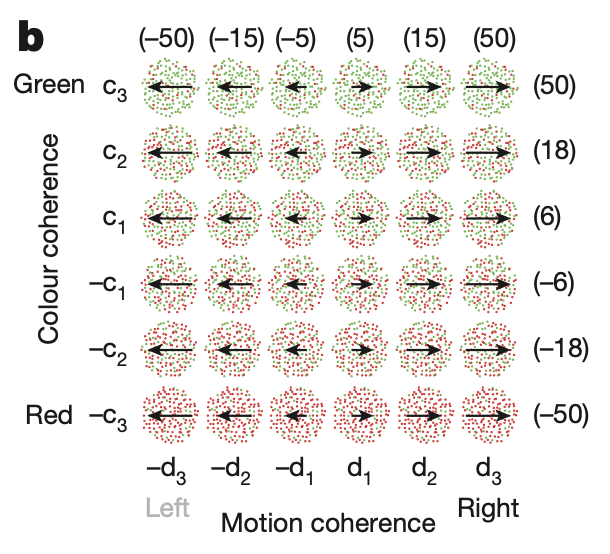

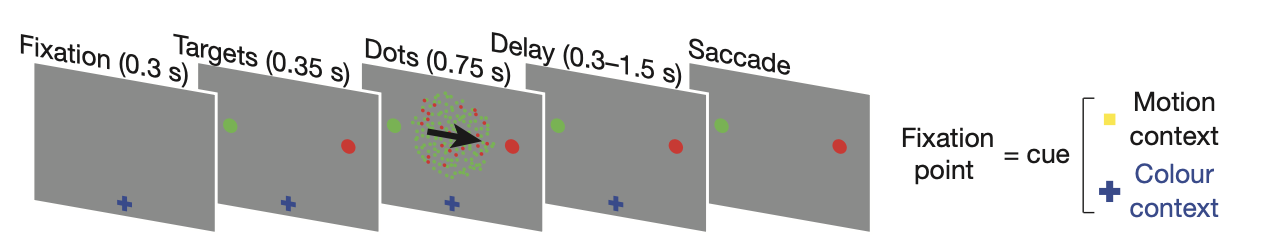

In [ ]:
def define_data_set(num_tasks, T):
    x_dataset = torch.zeros([num_tasks, 4, T])
    y_dataset = torch.zeros([num_tasks, T])

    # ground truth: context, color, motion (all +/- 1)
    #np.random.rand generates random numbers between 0 or 1 (transforming them into integers (int) and re-scaling gives us what we want)
    context_ = 2*np.random.rand(num_tasks) - 1
    context = 2*((context_<0.0).astype(int)) - 1

    color_ = 2*np.random.rand(num_tasks) - 1
    color = 2*((color_<0.0).astype(int)) - 1

    motion_ = 2*np.random.rand(num_tasks) - 1
    motion = 2*((motion_<0.0).astype(int)) - 1

    y_dataset_full = torch.cat((torch.tensor(motion).unsqueeze(1), torch.tensor(color).unsqueeze(1), torch.tensor(context).unsqueeze(1)), dim=1)

    #create data like in the paper: there is a fixation time [0, 0.2*T] and [0.8*T, T], and another task period where the animal
    #has access to the stimulus: [0.2*T, 0.8*T]
    fix_end = int(0.2 * T)
    stim_end = int(0.8 * T)

    # define target per timestep, y is a timeseries too
    for n in range(num_tasks):
        if context[n] == -1:
            y_dataset[n, fix_end:stim_end] = ... ##Exercise 1
            #y_dataset[n] = motion[n]
        else:
            y_dataset[n, fix_end:stim_end] = ... #Exercise 1 (cont.)
            #y_dataset[n] = color[n]

        # coherence
        coh = np.random.choice([0.05, 0.1, 0.2])  # slightly stronger
        # baseline noise
        motion_signal = 0.001*np.random.randn(T)
        color_signal  = 0.001*np.random.randn(T)
        # add stimulus
        motion_signal[fix_end:stim_end] += motion_[n] * coh
        color_signal[fix_end:stim_end]  += color_[n]  * coh

        #the animal sees both motion and color signal
        x_dataset[n,0,:] = torch.tensor(motion_signal)
        x_dataset[n,1,:] = torch.tensor(color_signal)

        #... and context input
        if context[n] == -1:
            x_dataset[n,2,:] = 1.0
            x_dataset[n,3,:] = 0.0
        else:
            x_dataset[n,2,:] = 0.0
            x_dataset[n,3,:] = 1.0

    return x_dataset, y_dataset, y_dataset_full

In [ ]:
x_dataset, y_dataset, y_dataset_full = define_data_set(10000, 750)
print("training data shapes", x_dataset.shape, y_dataset.shape)
training_dataset = TensorDataset(x_dataset, y_dataset)
training_data = DataLoader(training_dataset, batch_size=50, shuffle=True)

x_dataset2, y_dataset2, y_dataset_full2 = define_data_set(1000, 750)
print("testing data shapes", x_dataset2.shape, y_dataset2.shape)
testing_dataset = TensorDataset(x_dataset2, y_dataset2)
testing_data = DataLoader(testing_dataset, batch_size=len(x_dataset2), shuffle=False)

training data shapes torch.Size([10000, 4, 750]) torch.Size([10000, 750])
testing data shapes torch.Size([1000, 4, 750]) torch.Size([1000, 750])


Text(0, 0.5, 'y output (ground truth)')

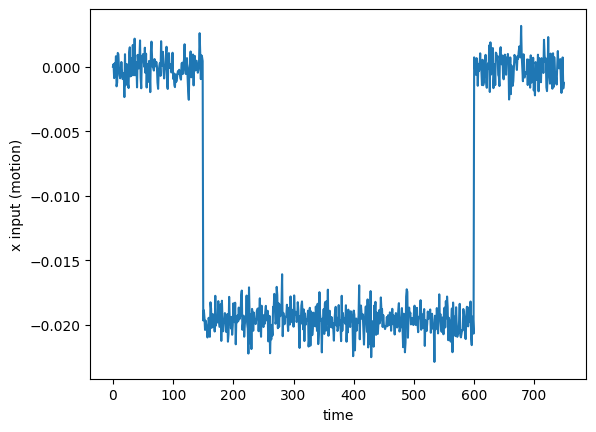

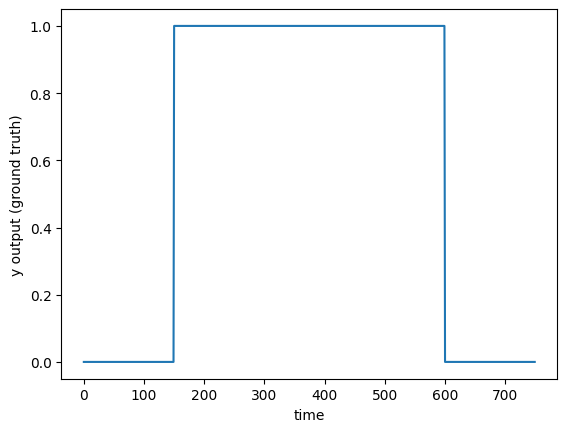

In [ ]:
#plot example input and output timeseries
trial = 0
plt.figure()
plt.plot(x_dataset[trial,0,:])
plt.xlabel("time")
plt.ylabel("x input (motion)")

plt.figure()
plt.plot(y_dataset[trial,:])
plt.xlabel("time")
plt.ylabel("y output (ground truth)")

**Section B: Define the RNN and train it**


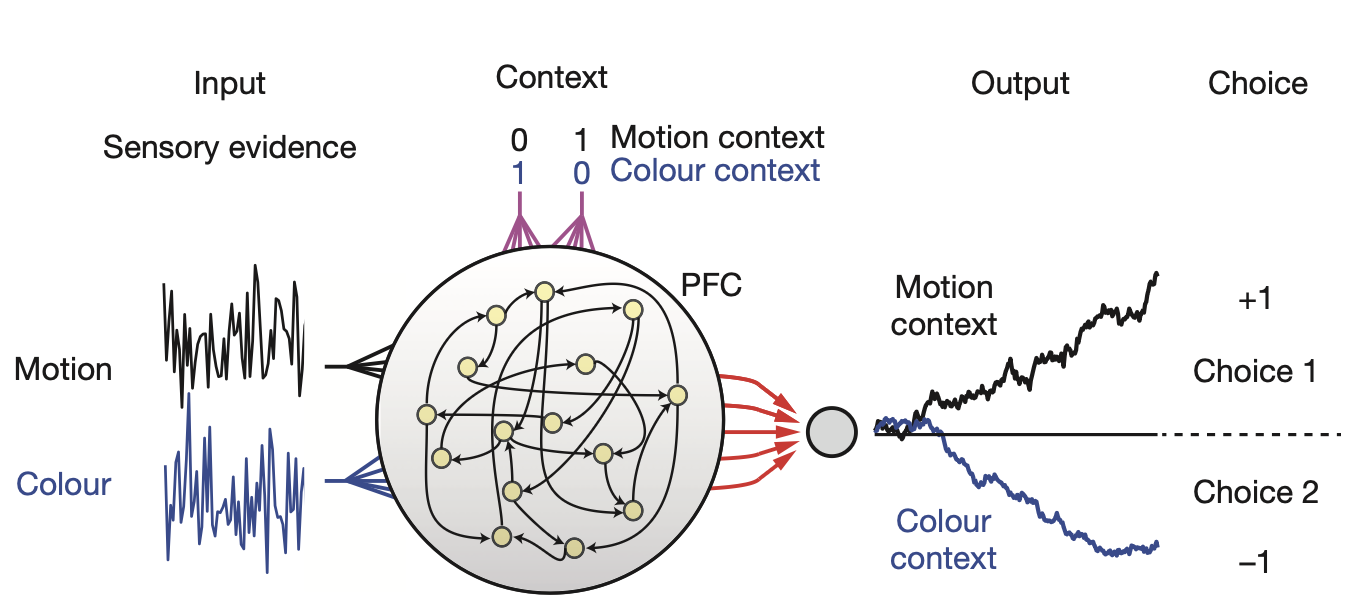

Figure 4, Mante and Sussillo (2013)

The equations describing the RNN are:

$\tau \dot{\textbf{h}} = -\textbf{h} + \textbf{J}\cdot \textbf{r} + \textbf{w}_1 \cdot i_m + \textbf{w}_2 \cdot i_{col} + \textbf{w}_3 \cdot i_{ctx-m} + \textbf{w}_4 \cdot i_{ctx-col}$

$\textbf{r} = \textrm{tanh}(\textbf{h})$

$\textrm{z} = \textbf{w}_{out}^T \cdot \textbf{r} + \textrm{b}$


In [ ]:
#define the RNN
class RNN_neuro(nn.Module):

     def __init__(self, input_size=4, hidden_size=100, output_size = 1, batchsize = 50, dt=1, **kwargs):
        super().__init__()

        self.J_weights = nn.Parameter(1.5*torch.randn(hidden_size, hidden_size)/np.sqrt(hidden_size), requires_grad=True)
        self.nonlinear_fn = nn.Tanh()

        self.fc_in = nn.Linear(input_size, hidden_size) #weights w_1, w_2, w_3, w_4
        self.fc_out = nn.Linear(hidden_size, output_size) #weights w
        self.bias = nn.Parameter(torch.randn(hidden_size), requires_grad = True)

        #parameters in the RNN
        self.std = 0.1
        self.tau = 10;
        self.dt = 1
        self.T = 750

        self.hidden_size = hidden_size

     def forward(self, input_):

        input_ = input_.float()
        batchsize = len(input_)
        device = input_.device

        #start with hidden layer at 0
        h = torch.zeros(batchsize, self.hidden_size, device=input_.device)
        r = self.nonlinear_fn(h).to(device)

        all_h = []; all_r = [];
        all_z = [];

        for t in range(self.T):
            input_term = self.fc_in(input_[:,:,t]) + self.bias
            noise = self.std*torch.randn(batchsize, self.hidden_size).to(device) #add noise (might result in better generalization)

            h = h + self.dt/self.tau * (-h + r @ self.J_weights.T.to(device) + ...) #Exercise 2 [fill in the blank] [Hint: two terms]
            r = self.nonlinear_fn(h)
            out = self.fc_out(r)

            all_h.append(h); all_r.append(r);
            all_z.append(out)

        all_h = torch.stack(all_h, dim=2)
        all_r = torch.stack(all_r, dim=2)
        all_z = torch.stack(all_z, dim=2)

        return all_z, all_h, all_r

In [ ]:
#define model, loss function, and the optimization algorithm
model = RNN_neuro()
model.float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()   # Mante uses MSE on final output

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device

True
Tesla T4


device(type='cuda')

.

In [ ]:
#train model
def train_model(model, training_data, num_epochs=5, batchsize=50, lr=1e-3, device = device):

    epoch_loss_arr = []
    epoch_acc_arr = []
    y_arr = []; X_arr = [];
    #z_final_arr = []; r_final_arr = []; h_final_arr = [];
    for epoch in range(num_epochs):

        epoch_loss = 0
        epoch_acc = 0
        epoch_total = 0
        for bid, batch in enumerate(training_data):

            X, y = batch
            X = X.to(device); y = y.to(device)
            batchsize, n_features, T = X.shape
            labels = y[:,int(T*0.5)] #labels is the +/- scalar corresponding to y

            # forward pass
            all_z, all_h, all_r = model(X)

            # final output at last time step (with stimulus), shape (batch, 1)
            z_final = all_z[:, 0, int(T*0.8) - 1]

            optimizer.zero_grad()
            # MSE loss target needs shape (batch,)
            #loss is computed over the time the stimulus is shown
            loss = loss_fn(all_z[:,0,int(T*0.2):int(T*0.8)], y[:,int(T*0.2):int(T*0.8)].float())

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            #what is the label we predict?
            preds = (z_final > 0).long()...  #Exercise 3
            correct = (preds == labels).sum().item()
            epoch_acc += correct
            epoch_total += batchsize

            epoch_loss_arr.append(loss)
            epoch_acc_arr.append(float(correct)/batchsize)
            #X_arr.append(X); y_arr.append(labels);
            #z_final_arr.append(all_z); h_final_arr.append(all_h); r_final_arr.append(all_r);

            if bid%25 == 0:
              print(f"acuracy at step {bid} is {correct/batchsize}")

        #compute accuracy
        epoch_acc = epoch_acc / epoch_total
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}%")

    #z_final_arr = torch.stack(z_final_arr).view(-1, model.T);
    #h_final_arr = torch.stack(h_final_arr).view(-1, model.hidden_size, model.T);
    #r_final_arr = torch.stack(r_final_arr).view(-1, model.hidden_size, model.T);
    #X_arr = torch.stack(X_arr); y_arr = torch.stack(y_arr).flatten()

    return epoch_loss_arr, epoch_acc_arr  #, X_arr, y_arr, h_final_arr, r_final_arr, z_final_arr

In [ ]:
def test_model(model, testing_data, device=device):

    model.eval()
    for bid, batch in enumerate(testing_data):

        X, y = batch
        X = X.to(device); y = y.to(device)
        batchsize, n_features, T = X.shape
        labels = y[:,int(T*0.5)]

        # forward pass
        all_z, all_h, all_r = model(X)

        # final output at last time step, shape (batch, 1)
        z_final = all_z[:, 0, int(T*0.8) - 1]

        #compute testing loss
        loss = loss_fn(all_z[:,0,int(T*0.2):int(T*0.8)], y[:,int(T*0.2):int(T*0.8)].float())

        preds = torch.sign(z_final)
        correct = (preds == y[:,int(T*0.5)]).sum().item()
        accuracy = correct/batchsize

    print(f"Testing loss is {loss.item()} and accuracy {accuracy*100}")
    return X, labels, all_z, all_h, all_r

.

In [ ]:
epoch_loss, epoch_acc = train_model(model, training_data, device = device)
#X_arr, y_arr, h_final_arr, r_final_arr, z_final_arr

acuracy at step 0 is 0.5
acuracy at step 25 is 0.4
acuracy at step 50 is 0.6
acuracy at step 75 is 0.74
acuracy at step 100 is 0.6
acuracy at step 125 is 0.8
acuracy at step 150 is 0.82
acuracy at step 175 is 0.88
Epoch   1/5 | Loss: 177.2386 | Acc: 63.56%
acuracy at step 0 is 0.7
acuracy at step 25 is 0.72
acuracy at step 50 is 0.9
acuracy at step 75 is 0.88
acuracy at step 100 is 0.84
acuracy at step 125 is 0.86
acuracy at step 150 is 0.92
acuracy at step 175 is 0.92
Epoch   2/5 | Loss: 103.9656 | Acc: 83.49%
acuracy at step 0 is 0.92
acuracy at step 25 is 0.96
acuracy at step 50 is 0.98
acuracy at step 75 is 0.86
acuracy at step 100 is 0.94
acuracy at step 125 is 0.66
acuracy at step 150 is 0.92
acuracy at step 175 is 0.94
Epoch   3/5 | Loss: 74.9746 | Acc: 90.14%
acuracy at step 0 is 0.98
acuracy at step 25 is 0.92
acuracy at step 50 is 0.92
acuracy at step 75 is 0.98
acuracy at step 100 is 0.88
acuracy at step 125 is 0.94
acuracy at step 150 is 0.9
acuracy at step 175 is 0.94
Epoc

In [ ]:
#test the model with a dataset it has never seen (testing_data)
X, y, all_z, all_h, all_r = test_model(model, testing_data)
X.shape, y.shape, all_r.shape, all_h.shape

Testing loss is 0.1633578985929489 and accuracy 96.5


(torch.Size([1000, 4, 750]),
 torch.Size([1000]),
 torch.Size([1000, 100, 750]),
 torch.Size([1000, 100, 750]))

.

Text(0, 0.5, 'loss')

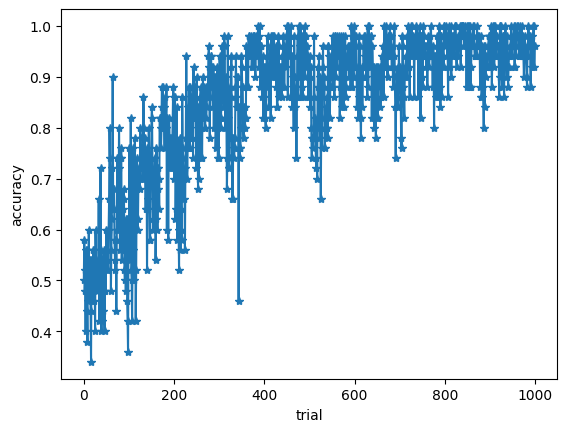

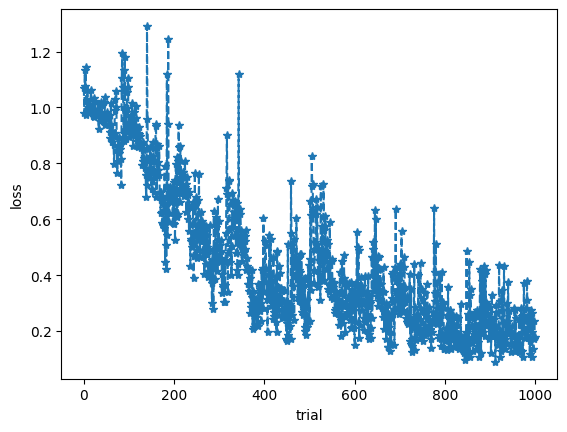

In [ ]:
#plot accuracy (increasing) and loss (decreasing) over learning trials
plt.figure()
plt.plot(epoch_acc, "-*")
plt.xlabel("trial")
plt.ylabel("accuracy")

epoch_loss = [epoch_loss[i].item() for i in range(len(epoch_loss))]
plt.figure()
plt.plot(epoch_loss, "--*")
plt.xlabel("trial")
plt.ylabel("loss")

From Mante et. al.:

> "... the recorded responses of single neurons
appeared to represent several different task-related signals at once including the monkey’s upcoming choice, the context, and the strength of
motion and colour evidence (Extended Data Figs 1 and 3). Rather than attempting to understand the neural mechanism underlying selective integration by studying the responses of single PFC neurons, we focussed on analysing the responses of the population as a whole. "



r_final_arr.shape torch.Size([1000, 100, 750])


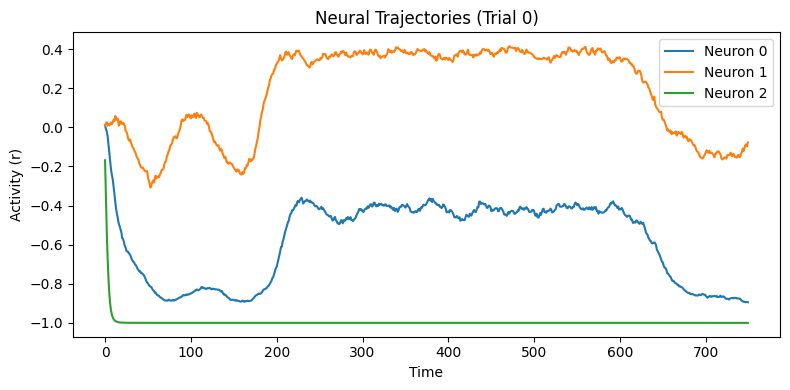

In [ ]:
#plot unit activities (from testing). This is in analogy to a firing rate of neurons in the brain
def plot_neural_trajectories(all_r, neuron_ids=[0,1,2], trial_id=0):
    r = all_r[trial_id,:,:].detach().cpu().numpy()  # shape (hidden, T)
    T = r.shape[1]

    plt.figure(figsize=(8,4))
    for nid in neuron_ids:
        plt.plot(range(T), r[nid,:], label=f"Neuron {nid}")

    plt.xlabel("Time")
    plt.ylabel("Activity (r)")
    plt.title(f"Neural Trajectories (Trial {trial_id})")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("r_final_arr.shape", all_r.shape)
plot_neural_trajectories(all_r)

.

**Section C: Visualize activity with dimensionality reduction**

In [ ]:
#indices corresponding to choices +/-1; context motion/color; motion left/right; color green/red; all are +/-1
y_ind0 = np.where(y.cpu() == -1)[0]
y_ind1 = np.where(y.cpu() == 1)[0]

context_ = y_dataset_full2[:,2]
context_ind0 = np.where(context_==-1)[0]
context_ind1 = np.where(context_==1)[0]

motion_ = y_dataset_full2[:,0]
motion_ind0 = np.where(motion_==-1)[0]
motion_ind1 = np.where(motion_==1)[0]

color_ = y_dataset_full2[:,1]
color_ind0 = np.where(...)[0]  #Exercise 4
color_ind1 = np.where(...)[0]

Vizualize the activity in a lower dimensional space

In [ ]:
all_r.shape #100 units... impossible to understand significant patterns (cannot just plot all neuron activity and make sense of it)

torch.Size([1000, 100, 750])

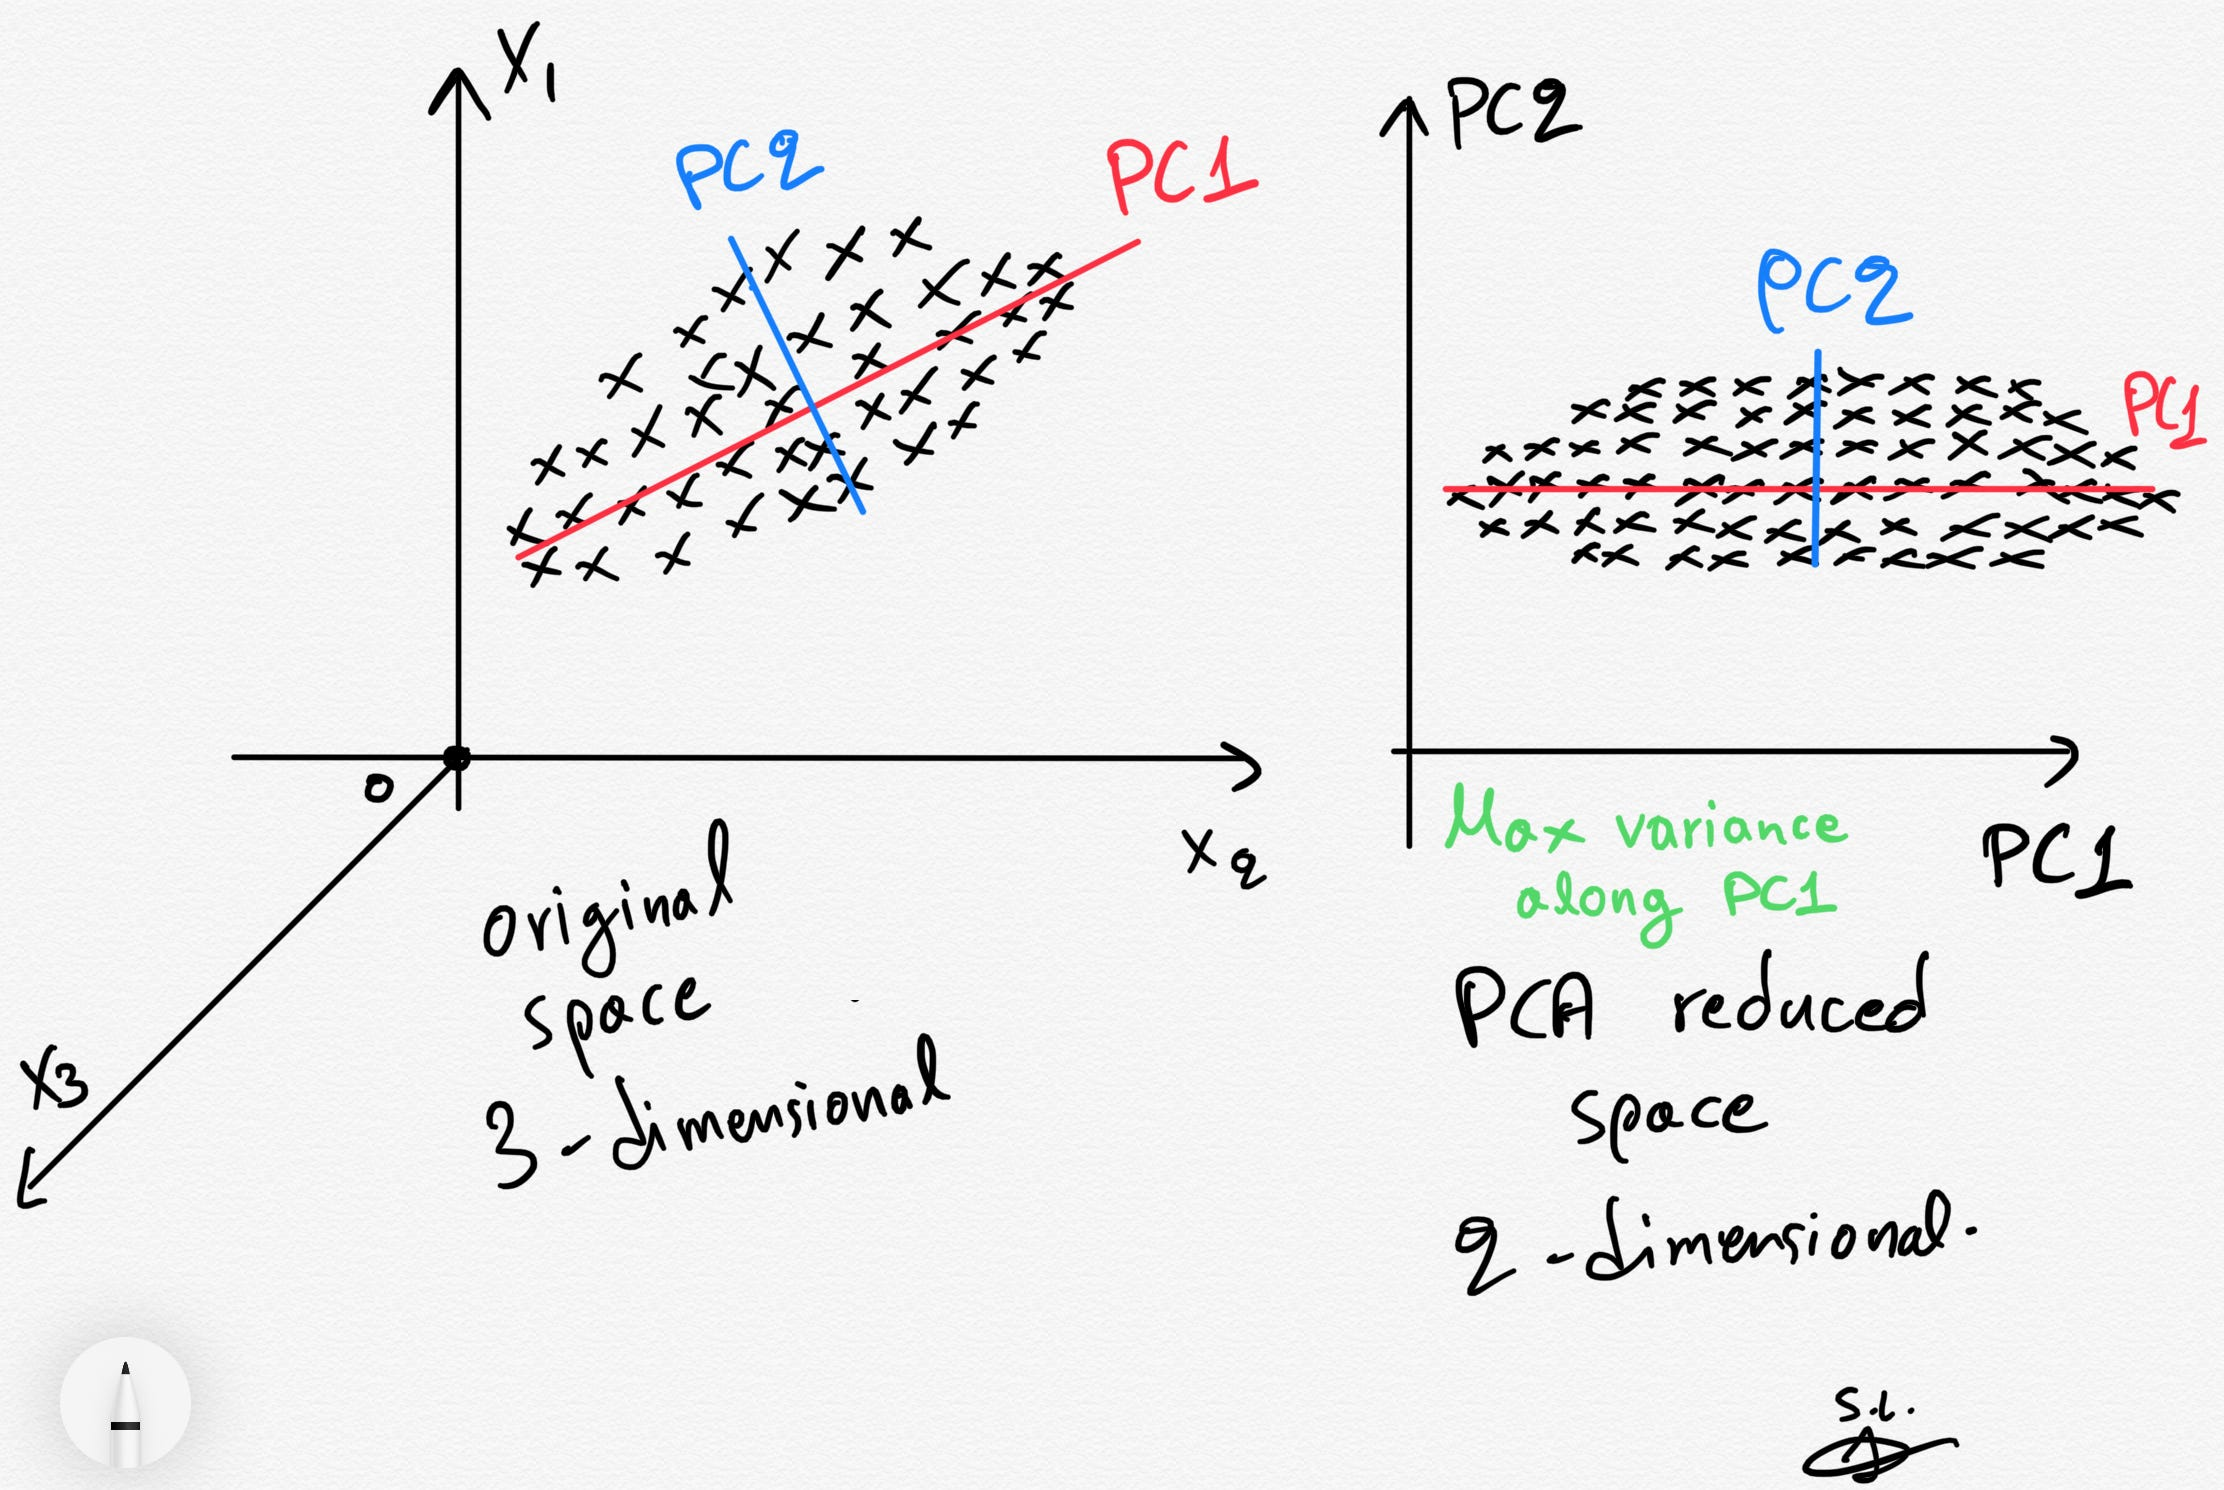

Figure from https://towardsdatascience.com/pca-clearly-explained-how-when-why-to-use-it-and-feature-importance-a-guide-in-python-7c274582c37e/

trajs.shape (6000, 100)
big_p.shape (6000, 3)


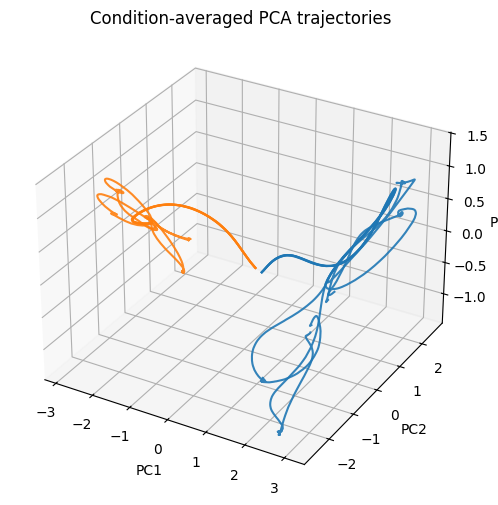

In [ ]:
#average trajectory for different conditions (ie motion, color, context)
def trial_average_by_condition(all_r, y_full):
    # y_full[:,0]=motion,[:,1]=color,[:,2]=context
    motion = y_full[:,0].cpu().numpy()
    color  = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    conds = {}
    for m in [-1,1]:
        for c in [-1,1]:
            for ctx in [-1,1]:
                mask = (motion==m) & (color==c) & (context==ctx)
                if mask.sum() == 0:
                    continue

                # average over trials for that condition
                avg = all_r[mask].mean(dim=0).cpu().detach().numpy()   # (H, T) #average trajectory over each condition
                conds[(m,c,ctx)] = avg
    return conds

#plot average trajectories in a common PCA space
def pca_plot_condition_trajectories(cond_trajs, n_components=3):
    # stack and fit PCA on concatenated time X conditions
    trajs = []
    keys = []
    for k,v in cond_trajs.items():
        # v: (H, T) -> transpose to (T, H)
        trajs.append(v.T)
        keys.append(k)

    big = np.concatenate(trajs, axis=0)   # (T*conds, H)
    print("trajs.shape", big.shape)

    pca = PCA(n_components=n_components)
    big_p = pca.fit_transform(big)        # (T*conds, n_components)
    print("big_p.shape", big_p.shape)

    # split back and plot
    idx = 0
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    for k,v in zip(keys, trajs):
        T = v.shape[0]
        seg = big_p[idx:idx+T]
        ctx = k[2]
        color = 'C0' if ctx==-1 else 'C1'
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color=color, alpha=0.9)
        idx += T
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    plt.title('Condition-averaged PCA trajectories')
    plt.show()

conds = trial_average_by_condition(all_r, y_dataset_full2)
pca_plot_condition_trajectories(conds)


In [ ]:
all_r.shape

torch.Size([1000, 100, 750])

In [ ]:
np.transpose(all_r.cpu().detach().numpy(), (0,2,1)).reshape(-1, all_r.shape[1]).shape

(750000, 100)

In [ ]:
#do PCA on all trajectories
#the dimensionality being reduced is the unit dimension (from 100 to 2 or 3, so we can visualize)
def pca_plot_trajectories(all_r, list_of_trials, n_components=3):
    # stack and fit PCA on concatenated time X conditions

    batch, n_units, t = all_r.shape

    big = np.transpose(all_r.cpu().detach().numpy(), (0,2,1)).reshape(-1, all_r.shape[1])   # (T*conds, H)
    print("trajs.shape", big.shape)

    pca = PCA(n_components=n_components)
    big_p = pca.fit_transform(big)        # (T*batch, n_components)
    big_p = big_p.reshape(...) #Exercise 5
    print("big_p.shape", big_p.shape)

    # split back and plot
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')

    for idx in list_of_trials:
      ax.plot(big_p[idx,:,0], big_p[idx,:,1], big_p[idx,:,2])

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    plt.title('Condition-averaged PCA trajectories')
    plt.show()

trajs.shape (750000, 100)
big_p.shape (1000, 750, 3)


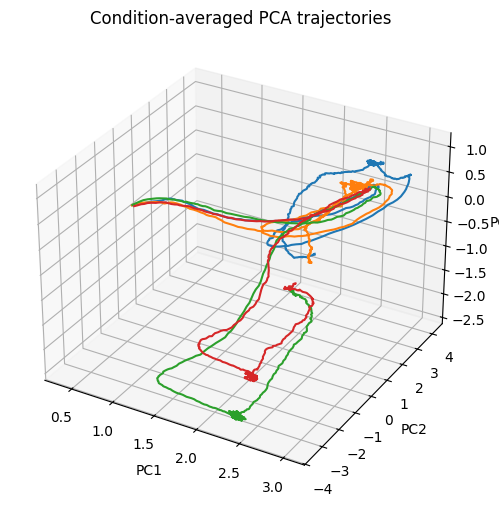

In [ ]:
list_of_trials = list(y_ind0[:2]) + list(y_ind1[:2]) #some trials choosing +1, some trials choosing -1
pca_plot_trajectories(all_r, list_of_trials)

Investigate a different set of axes

In [ ]:
#two ways of computing a (model-driven) choice axis
def compute_choice_axes(model, all_r, y):

    # model.fc_out.weight: (1, hidden)
    choice_axis_model = model.fc_out.weight.data.squeeze(0)          # torch (H,)
    choice_axis_model = choice_axis_model / choice_axis_model.norm()  #normalize this axis for unit norm

    # regression-based choice axis (fit final choice using population at final time)
    with torch.no_grad():
        R_final = all_r[:, :, -1].cpu().detach().numpy()  # (B, H)
        y_np = y.cpu().detach().numpy().reshape(-1, 1)              # (B,1)

    # ridge to get direction in H space: solve R_final @ w = y
    ridge = Ridge(alpha=1.0, fit_intercept=False)
    ridge.fit(R_final, y_np)

    w = ridge.coef_.reshape(-1)    # shape (H,)
    w = w / np.linalg.norm(w)
    choice_axis_ridge = torch.from_numpy(w).float()

    return choice_axis_model.detach(), choice_axis_ridge

In [ ]:
def project_and_summary(all_r, axis, y=None, to_plot=[0], col=0, suppress = False):

    all_r = all_r.cpu()
    axis = axis.to(all_r.device)

    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()

    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer
    #proj = torch.einsum('bht,h->bt', all_r, axis)
    if len(axis.shape)==1:
      axis = axis.unsqueeze(0)

    r_btH = all_r.transpose(1, 2).float()   # [B, T, H]
    axis = axis.transpose(1,0).float() # [H, 1 or 4]
    proj = torch.matmul(...)  # [B, T, 1 or 4]. #project on axes #Exercise 6
    proj_np = proj.detach().cpu().numpy()
    proj_np = proj.cpu().detach().numpy()

    print("proj_np.shape", proj_np.shape)
    #separate projectiom across trials for choice +1/-1, and take mean/std of projections
    mean_plus = proj_np[(y==1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    mean_minus= proj_np[(y==-1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    sem_plus  = proj_np[(y==1).cpu().numpy(),:,:].std(axis=0, ddof=1) / np.sqrt((y==1).sum().item()) if y is not None else None
    sem_minus = proj_np[(y==-1).cpu().numpy(),:,:].std(axis=0, ddof=1)/ np.sqrt((y==-1).sum().item()) if y is not None else None

    T = mean_plus.shape[0]
    t = np.arange(T)

    ind0 = np.where((y==-1).cpu().numpy())[0]
    ind0 = ind0[np.random.choice(len(ind0),10)] #ind0[-100:]
    ind1 = np.where((y==1).cpu().numpy())[0]
    ind1 = ind1[np.random.choice(len(ind1),10)] #ind1[-100:]

    axis_names = []
    if 0 in to_plot:
        axis_names.append("choice axis")
    if 1 in to_plot:
        axis_names.append("motion axis")
    if 2 in to_plot:
        axis_names.append("color axis")
    if 3 in to_plot:
        axis_names.append("context axis")

    if len(axis_names) == 1:
        plt.figure(figsize=(7,4))
        plt.plot(t, proj_np[ind0,:,to_plot[0]].T, color='blue', alpha=0.2)
        plt.plot(t, proj_np[ind1,:,to_plot[0]].T, color = 'orange', alpha=0.2)
        plt.xlabel("Time")
        plt.ylabel("Projection")
    else:
        plt.figure()
        if len(ind0) != 0:
          plt.plot(proj_np[ind0, int(0.2*T):int(0.8*T), to_plot[0]].T, proj_np[ind0, int(0.2*T):int(0.8*T), to_plot[1]].T, color = "C" + str(col))

        if len(ind1) != 0:
          plt.plot(proj_np[ind1, int(0.2*T):int(0.8*T), to_plot[0]].T, proj_np[ind1, int(0.2*T):int(0.8*T), to_plot[1]].T, color = "C" + str(col+1))

        plt.xlabel(axis_names[0])
        plt.ylabel(axis_names[1])


    if suppress == False:
        plt.figure()
        plt.fill_between(t, mean_minus[:,0]-sem_minus[:,0], mean_minus[:,0]+sem_minus[:,0], alpha=0.5, color='C0')
        plt.plot(t, mean_minus[:,0], label='-1', color='C0')
        plt.fill_between(t, mean_plus[:,0]-sem_plus[:,0], mean_plus[:,0]+sem_plus[:,0], alpha=0.5, color='C1')
        plt.plot(t, mean_plus[:,0], label='+1', color='C1')
        plt.xlabel('Time')
        plt.ylabel('Projection')
        plt.title('Average projection over time')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return proj_np

proj_np.shape (1000, 750, 1)


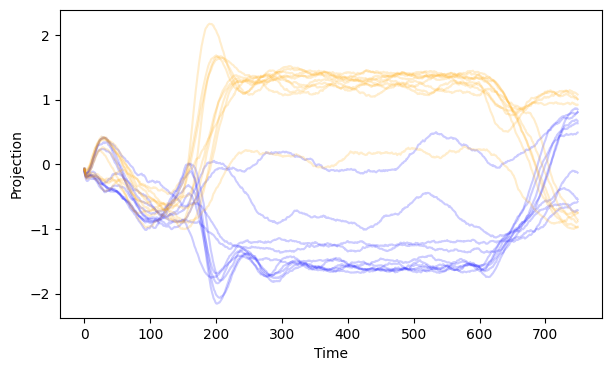

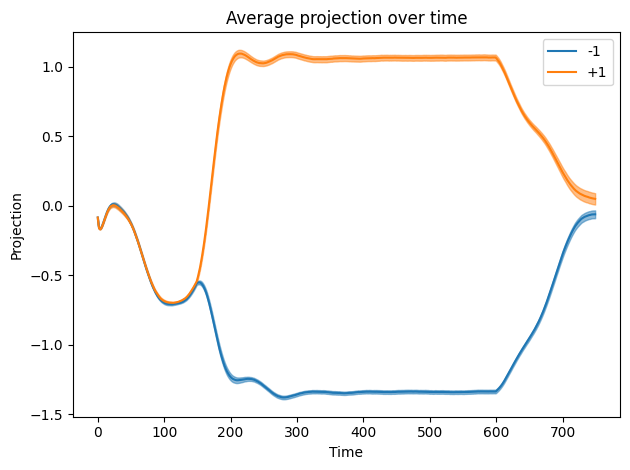

In [ ]:
choice_axis_model, choice_axis_ridge = compute_choice_axes(model, all_r, y)
#context_axis = compute_context_axis(r_final_arr, X_arr)
proj_np = project_and_summary(all_r, choice_axis_model, y)

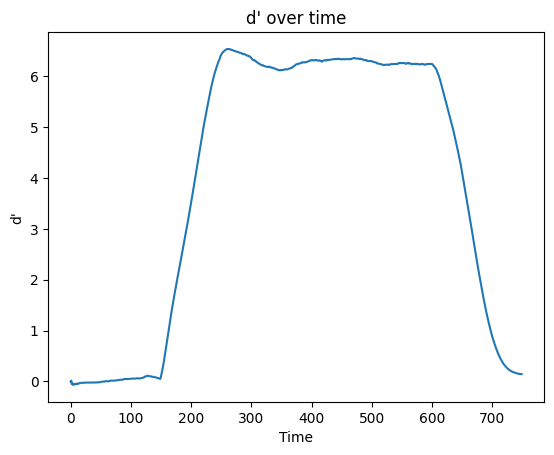

In [ ]:
#does this projection separate well based on choice?
def compute_dprime_over_time(proj, y):
    # proj: (B, T)
    #select trials with +1 or -1 choice consider their projection on the choice axis
    mu_p = proj[y==1].mean(axis=0)
    mu_m = proj[y==-1].mean(axis=0)
    var_p = proj[y==1].var(axis=0, ddof=1)
    var_m = proj[y==-1].var(axis=0, ddof=1)

    # pooled sd
    # compute d', high d' > 3 indicates there is clear separation along the axis of choice
    sd_pooled = np.sqrt(0.5*(var_p + var_m))
    dprime = (mu_p - mu_m) / (sd_pooled + 1e-10)
    return dprime

dprime = compute_dprime_over_time(proj_np, y.cpu())
plt.figure(); plt.plot(dprime); plt.xlabel('Time'); plt.ylabel("d'"); plt.title("d' over time"); plt.show()

Compute axis of motion, color, context, and choice (like in the paper)
This is to better visualize results and infer dynamics

From the paper (supplementary material):

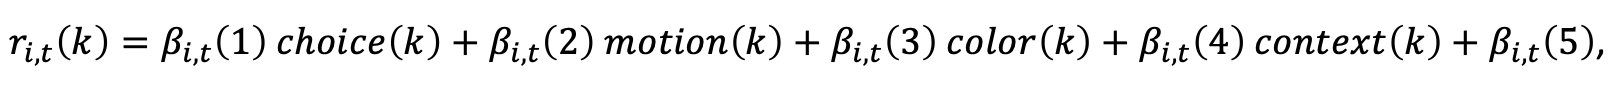

The unit activities $r$ are regressed against choice, motion, color, and context.

This is a data-driven way to compute axes (as opposed to model-driven, like before!

In [ ]:
def compute_betas(all_r, y_full,y):
    # all_r: (B, H, T)
    B, H, T = all_r.shape
    betas = np.zeros((T, H, 4))  # choice, motion, color, context

    #select choice, motion, color, context for all trials
    choice  = y.cpu().numpy()
    motion  = y_full[:,0].cpu().numpy()
    color   = y_full[:,1].cpu().numpy()
    context = y_full[:,...].cpu().numpy() #Exercise 7: which coordinate of y_full stores context information? (y_full is the y_dataset_full2 matrix)
    #constant = torch.ones_like(y).cpu().numpy()

    X = np.stack([choice, motion, color, context], axis=1)
    X = X - X.mean(axis=0, keepdims=True)
    X = X / X.std(axis=0, keepdims=True)

    #for each time t and for each unit, do the regression
    for t in range(T):
        for h in range(H):
            y = all_r[:,h,t].cpu().detach().numpy()
            reg = LinearRegression().fit(X, y)
            betas[t,h,:] = reg.coef_[:4]

    #get a T x N_units(100)x 4 basis.
    return betas

def max_norm_axes(betas):
    # betas: (T, H, 4)
    #The time dimension is a nuisance, so we just consider the axis with the highest norm through time
    axes = []
    for k in range(4):
        norms = np.linalg.norm(betas[:,:,k], axis=1)
        t_star = norms.argmax()
        axes.append(betas[t_star,:,k])
    return np.stack(axes)

betas = compute_betas(all_r, y_dataset_full2, y_dataset2[:,750//2])
print("betas.shape", betas.shape)

beta_axes = max_norm_axes(betas)

#do a QR decomposition as well, by which we orthogonalize the axes (ie disentangle their directions so that they are independent)
Q, R = qr(beta_axes.T)
axes_orth = torch.from_numpy(Q.T)

betas.shape (750, 100, 4)


In [ ]:
axes_orth.shape, all_r.shape, y_dataset_full2.shape, y_dataset2.shape

(torch.Size([4, 100]),
 torch.Size([1000, 100, 750]),
 torch.Size([1000, 3]),
 torch.Size([1000, 750]))

In [ ]:
#what is the angle between the choice axis that is computed above after orthogonalization, and the choice axis given by the model's weights?
#to see how these axes compare
beta_choice = axes_orth[0]

w_out = model.fc_out.weight.detach().cpu().numpy().reshape(-1)
w_out = w_out / np.linalg.norm(w_out)

beta_choice = beta_choice / np.linalg.norm(beta_choice)

print("cos(readout, choice axis):", np.dot(w_out, beta_choice))

cos(readout, choice axis): 0.5204423131165968


/tmp/ipython-input-3724464823.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print("cos(readout, choice axis):", np.dot(w_out, beta_choice))


.

proj_np.shape (1000, 750, 4)


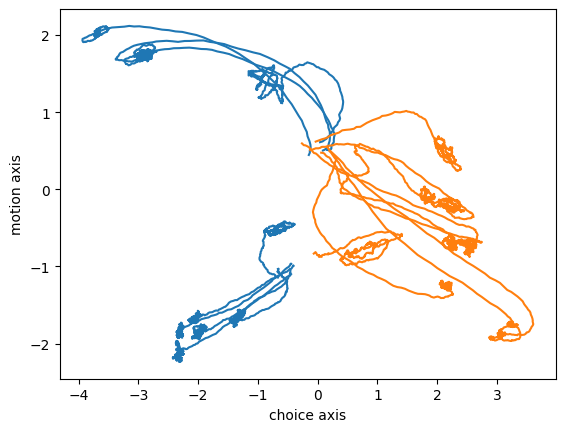

In [ ]:
proj = project_and_summary(all_r, axes_orth, y, to_plot=[0,1], suppress=True)

In [ ]:
axes_orth.shape

torch.Size([4, 100])

proj_np.shape (509, 750, 4)
proj_np.shape (509, 750, 4)


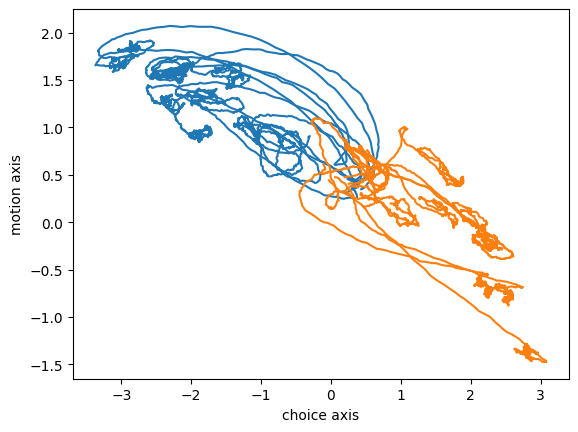

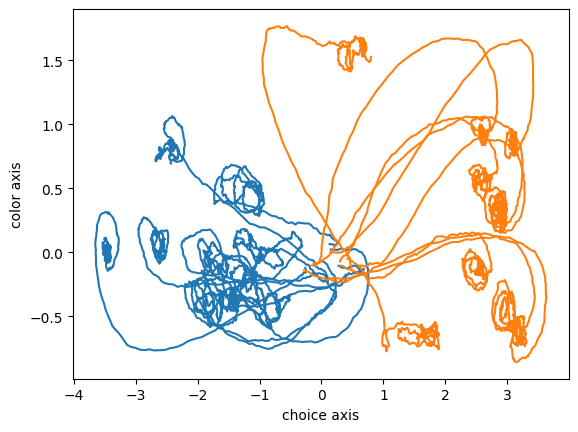

In [ ]:
#look at dynamics, motion context
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,1], suppress = True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], suppress = True)


proj_np.shape (509, 750, 4)


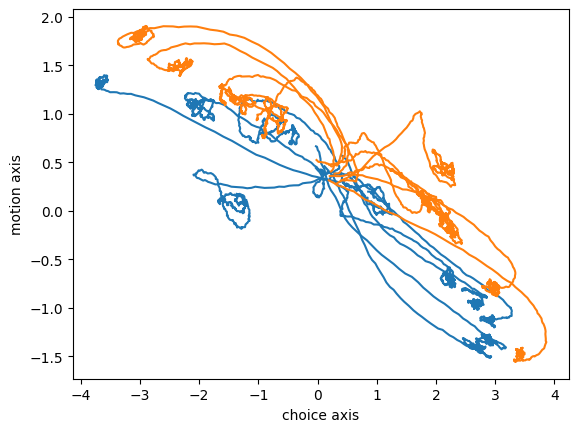

In [ ]:
#look at dynamics, motion context, but color labels (see how here these are mixed! i.e. mixed blue and orange trajectories)
ind_to_plot0 = list(set(color_ind0) & set(context_ind0))
ind_to_plot1 = list(set(color_ind1) & set(context_ind0))

proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y_dataset_full2[ind_to_plot0+ind_to_plot1,1],  to_plot=[0,1], suppress = True)


proj_np.shape (491, 750, 4)
proj_np.shape (491, 750, 4)


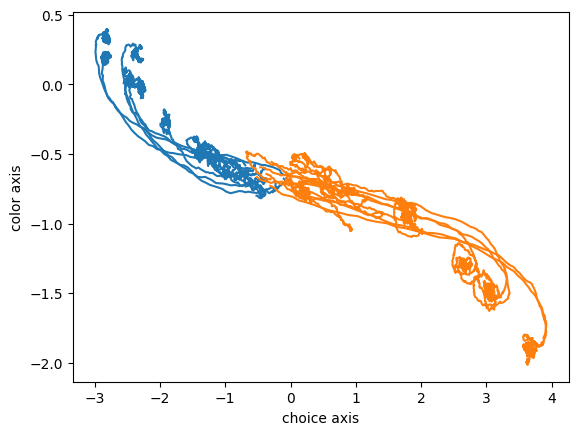

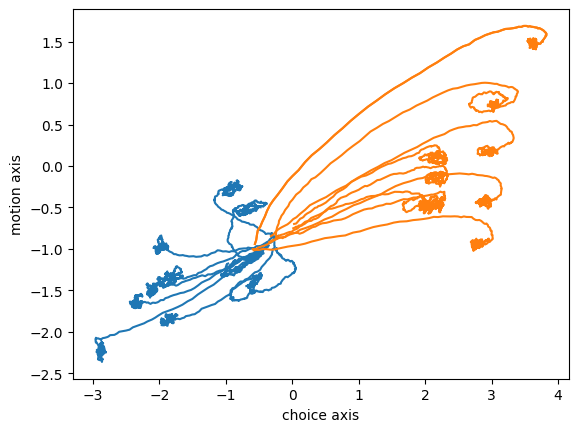

In [ ]:
#look at dynamics, color context
ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], suppress=True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,1], suppress=True)

proj_np.shape (491, 750, 4)


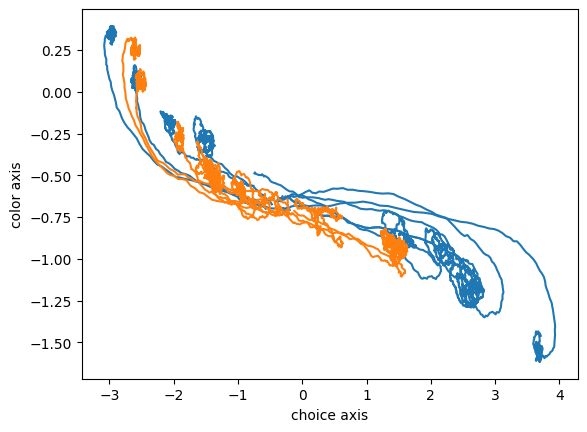

In [ ]:
#look at dynamics, color context, but by motion label -- you should see the blue and orange trajectories are all mixed, proof that color is
#not influencing decision
ind_to_plot0 = list(set(motion_ind0) & set(context_ind1))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind1))
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y_dataset_full2[ind_to_plot0+ind_to_plot1,0], to_plot=[0,2], suppress=True)

Mante data analysis (Figure 2)

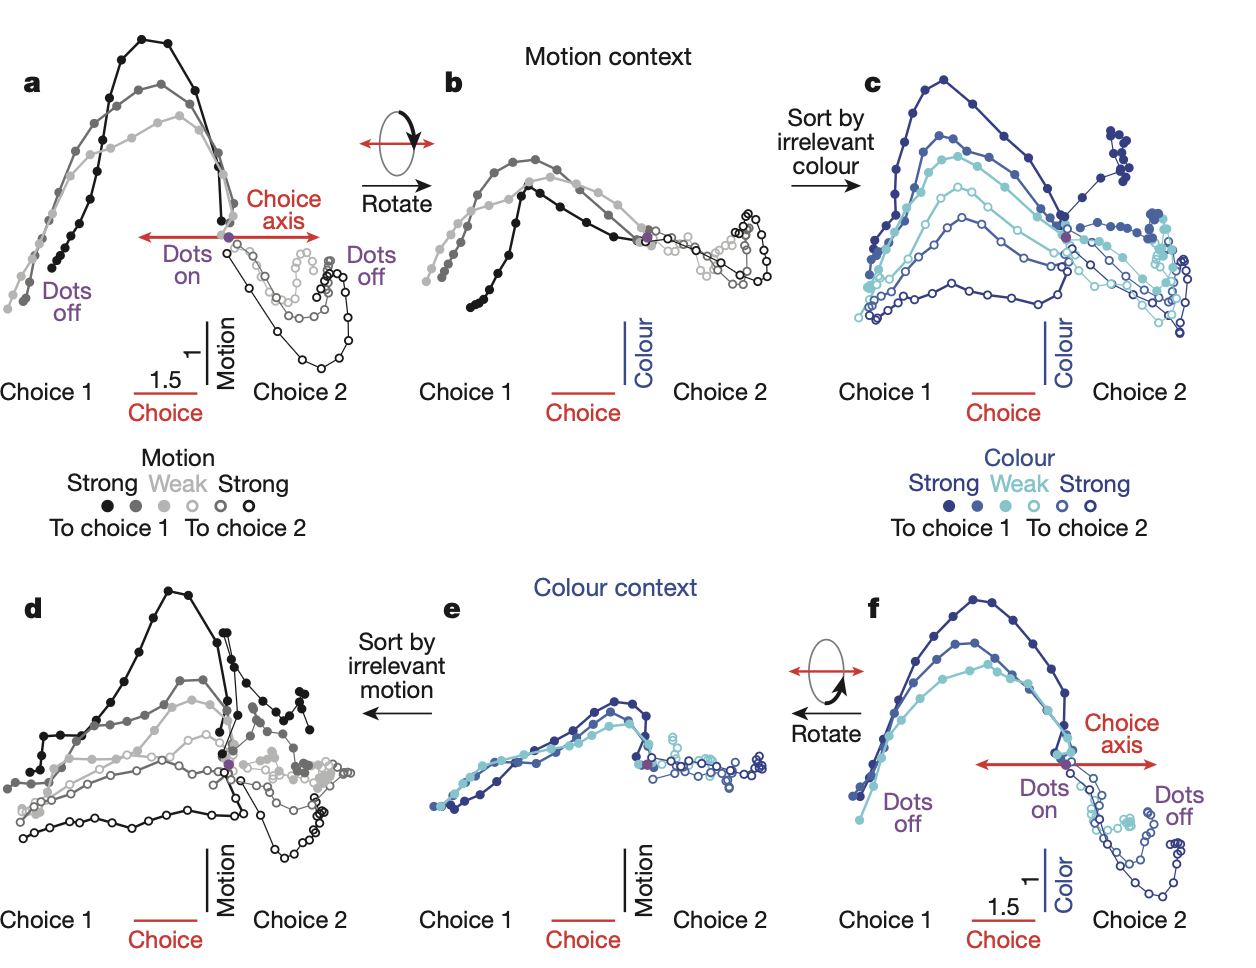

In [ ]:
def project_and_col_intensity(all_r, axis, y_colors=None, to_plot=[0]):

    all_r = all_r.cpu()
    axis = axis.to(all_r.device)
    y_colors = y_colors.to(all_r.device)

    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()

    batchsize, N_units, T = all_r.shape; #[B, N, T] = [1000, 100, 750]

    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer
    #proj = torch.einsum('bht,h->bt', all_r, axis)
    if len(axis.shape)==1:
      axis = axis.unsqueeze(0)

    r_btH = all_r.transpose(1, 2).float()   # [B, T, H]
    axis = axis.transpose(1,0).float() # [H, 1 or 4]
    proj = torch.matmul(r_btH, axis)  # [B, T, 1 or 4]. #project on axes #Exercise
    proj_np = proj.cpu().detach().numpy()

    axis_names = []
    if 0 in to_plot:
        axis_names.append("choice axis")
    if 1 in to_plot:
        axis_names.append("motion axis")
    if 2 in to_plot:
        axis_names.append("color axis")
    if 3 in to_plot:
        axis_names.append("context axis")

    if y_colors is not None:
        y_colors = np.array(y_colors).astype(float)
        import matplotlib.cm as cm
        import matplotlib.colors as colors
        norm = colors.Normalize(vmin=y_colors.min(), vmax=y_colors.max())
        cmap = cm.viridis

    list_of_inds = np.random.choice(len(y_colors), 100)
    for i in list_of_inds:

        if y_colors is not None:
            color_i = cmap(norm(y_colors[i]))
        else:
            color_i = "black"

        if len(axis_names) == 1:
            plt.plot(proj_np[i,:,to_plot[0]], color=color_i, alpha=0.4)
            plt.xlabel("Time")
            plt.ylabel("Projection")
        else:
            plt.plot(proj_np[i, int(0.2*T):int(0.8*T), to_plot[0]], proj_np[i, int(0.2*T):int(0.8*T), to_plot[1]], color=color_i, alpha=0.5)
            plt.xlabel(axis_names[0])
            plt.ylabel(axis_names[1])

    return proj_np

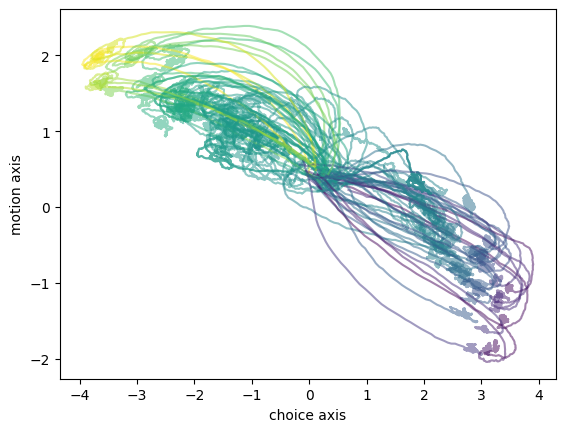

In [ ]:
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))
y_colors_motion = X[:,0,int(0.3*X.shape[2]):int(0.7*X.shape[2])].mean(1)

all_r_to_plot = all_r[ind_to_plot0+ind_to_plot1]
y_colors_motion_to_plot = y_colors_motion[ind_to_plot0+ind_to_plot1]
proj_np = project_and_col_intensity(all_r_to_plot, axes_orth, y_colors=y_colors_motion_to_plot, to_plot=[0,1])

In [ ]:
"""
import numpy as np
import torch
from sklearn.linear_model import Ridge
from numpy.linalg import qr

def mante_regression_pipeline(
        all_r,          # (B, H, T)
        y_full,         # (B, 3) → motion, color, context
        y_choice,       # (B,)
        stim_frac=(0.2, 0.8),
        alpha=1.0       # Ridge regularization strength
    ):


    B, H, T = all_r.shape

    # ---------------------- 1. Stimulus window ----------------------
    t0 = int(stim_frac[0] * T)
    t1 = int(stim_frac[1] * T)

    # ---------------------- 2. Prepare regressors ----------------------
    choice  = y_choice.cpu().numpy()
    motion  = y_full[:,0].cpu().numpy()
    color   = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()

    # stack into (B × 4)
    X = np.stack([choice, motion, color, context], axis=1)

    # center regressors (Mante does this)
    X = X - X.mean(axis=0, keepdims=True)

    # ---------------------- 3. Z-score firing rates ----------------------
    r_np = all_r.cpu().numpy()
    r_np = (r_np - r_np.mean(axis=0, keepdims=True)) / (r_np.std(axis=0, keepdims=True) + 1e-6)

    # ---------------------- 4. Initialize betas ----------------------
    betas = np.zeros((T, H, 4))

    # ---------------------- 5. Regression (within stimulus window) ----------------------
    reg = Ridge(alpha=alpha)

    for t in range(t0, t1):
        for h in range(H):
            y_r = r_np[:, h, t]
            reg.fit(X, y_r)
            betas[t, h, :] = reg.coef_

    # ---------------------- 6. Extract max-norm axes ----------------------
    axes = []
    for k in range(4):
        norms = np.linalg.norm(betas[:, :, k], axis=1)     # norm over units
        t_star = norms.argmax()
        axes.append(betas[t_star, :, k])

    beta_axes = np.stack(axes)   # (4 × H)

    # ---------------------- 7. Orthogonalize with QR ----------------------
    Q, R = qr(beta_axes.T)
    axes_orth = Q.T              # (4 × H)

    return {
        "betas": betas,
        "beta_axes": beta_axes,
        "axes_orth": axes_orth,
        "stim_window": (t0, t1)
    }
"""

corr between proj dim 0 and 1: tensor([[ 1.0000, -0.1349],
        [-0.1349,  1.0000]], grad_fn=<ClampBackward1>)


.

**Section D : Compute fixed points**

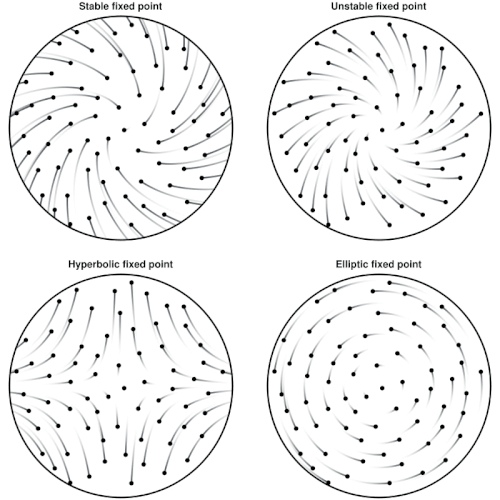


GIF from https://en.wikipedia.org/wiki/Stability_theory

In [ ]:
#model vector field that gives loss function to find fixed point
def model_vector_field(h, x_const, model):
    """
    Computes F(h) = -h + J tanh(h) + Bx + b
    """

    r = model.nonlinear_fn(h)
    # J r  (shape: hidden_size)
    Jr = r @ model.J_weights.T

    # B x  (shape: hidden_size)
    Bx = model.fc_in(x_const)

    # F(h)
    F = -h + Jr + Bx + model.bias

    return F

In [ ]:
#optimization to find fixed point
def find_fixed_point(X, all_h, model, trial, time_idx, max_iter=1000, tol=1e-8):

    # initial guess from trajectory
    h = all_h[trial, :, time_idx].clone().detach().requires_grad_(True)

    # hold input fixed at this timestep
    x_const = X[trial, :, time_idx]

    #optimization
    optimizer = torch.optim.Adam([h], lr=1e-2)
    loss_arr = []; h_star_arr = []
    for i in range(max_iter):

        F = model_vector_field(h, x_const, model)
        loss = (F**2).sum() #minimizing (-h + J*r + Bx +bias)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, loss = {loss.item():.3e}")

        #until loss is very small
        if loss.item() < tol:
            break

        loss_arr.append(loss.item()); h_star_arr.append(h.detach().cpu().clone().numpy())
    h_star = h.detach()
    r_star = model.nonlinear_fn(h_star)

    return h_star, r_star, loss.item(), loss_arr, h_star_arr

In [ ]:
h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X=X, all_h=all_h, model=model, trial=0, time_idx=int(0.75 * 750))
print("final FP loss:", final_loss)

Iter 0, loss = 2.577e-01
Iter 100, loss = 1.006e-04
Iter 200, loss = 3.819e-07
final FP loss: 9.796115918447867e-09


Text(0, 0.5, 'loss')

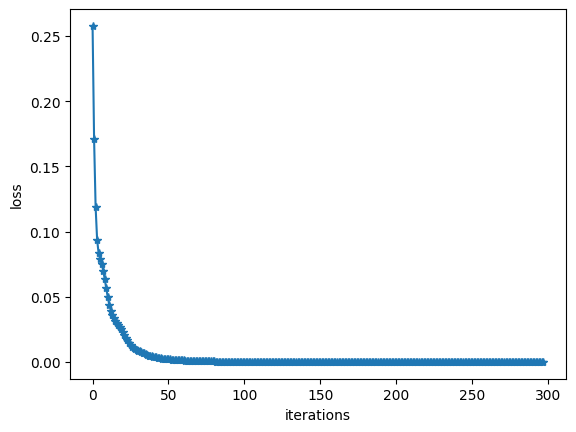

In [ ]:
plt.plot(loss_arr, "*-")
plt.xlabel("iterations")
plt.ylabel("loss")

Text(0.5, 1.0, 'zoom in around fixed point')

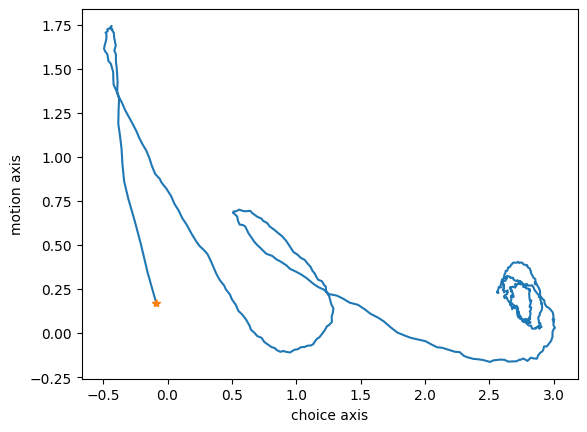

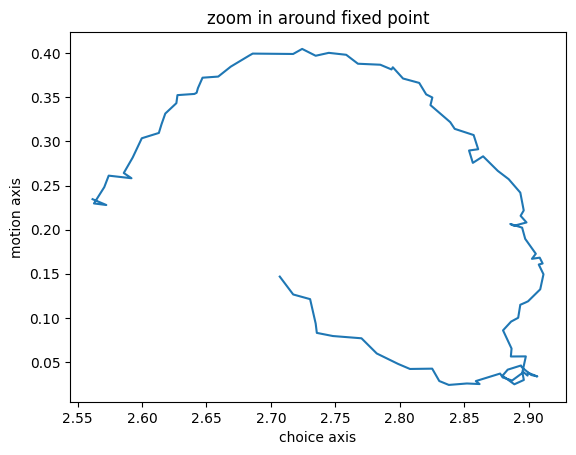

In [ ]:
#plot a trajectory (as well as zoomed-in version near fixed point)
trial = 0
rr = model.nonlinear_fn(all_h[trial,:,:])
proj_rr = torch.matmul(rr.T.float().cpu(), axes_orth.T.float())
plt.plot(proj_rr[:int(0.7*750),0].detach().numpy(), proj_rr[:int(0.7*750),1].detach().numpy())
plt.plot(proj_rr[0,0].detach().numpy(), proj_rr[0,1].detach().numpy(), "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")

#zoom in
plt.figure()
plt.plot(proj_rr[int(0.7*750)-100:int(0.7*750),0].detach().numpy(), proj_rr[int(0.7*750)-100:int(0.7*750),1].detach().numpy())
plt.xlabel("choice axis")
plt.ylabel("motion axis")
plt.title("zoom in around fixed point")

Text(0.5, 1.0, 'tanh(h star) iter projected on choice and motion axis')

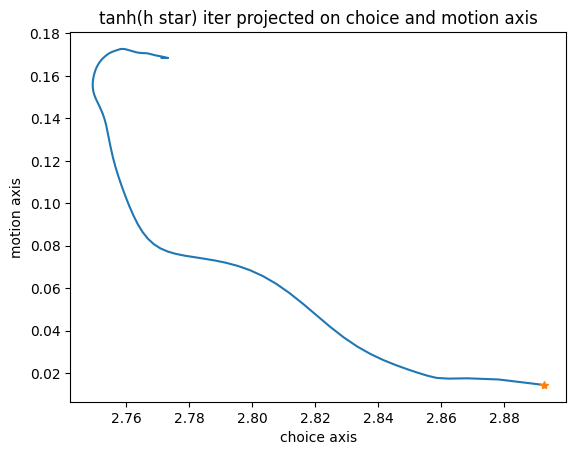

In [ ]:
#now look around computed fixed point
h_star_arr = np.stack(h_star_arr)
rr = model.nonlinear_fn(torch.from_numpy(h_star_arr))
proj_rr = torch.matmul(rr.float(), axes_orth.T.float())

plt.plot(proj_rr[:int(0.7*750),0].detach().numpy(), proj_rr[:int(0.7*750),1].detach().numpy())
plt.plot(proj_rr[0,0].detach().numpy(), proj_rr[0,1].detach().numpy(), "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")
plt.title("tanh(h star) iter projected on choice and motion axis")

.

In [ ]:
#compute fixed points for all trials in the testing set
proj_star_arr = []
for i in range(len(X)):
    print(i)
    h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X, all_h, model, i, time_idx=int(0.7 * 750))
    r_star = model.nonlinear_fn(h_star)

    proj_star = torch.matmul(r_star.float().cpu(), axes_orth.T.float())
    proj_star_arr.append(proj_star)

proj_star_arr = torch.stack(proj_star_arr)

Streaming output truncated to the last 5000 lines.
Iter 300, loss = 1.738e-05
Iter 400, loss = 9.458e-06
Iter 500, loss = 4.631e-06
Iter 600, loss = 2.086e-06
Iter 700, loss = 1.071e-05
Iter 800, loss = 2.978e-07
Iter 900, loss = 2.887e-07
136
Iter 0, loss = 1.056e-01
Iter 100, loss = 2.726e-06
Iter 200, loss = 2.290e-08
137
Iter 0, loss = 9.626e-02
Iter 100, loss = 9.826e-07
138
Iter 0, loss = 9.693e-02
Iter 100, loss = 1.871e-05
Iter 200, loss = 1.251e-07
139
Iter 0, loss = 2.061e-01
Iter 100, loss = 5.763e-05
Iter 200, loss = 1.688e-06
Iter 300, loss = 1.231e-08
140
Iter 0, loss = 2.733e-01
Iter 100, loss = 6.195e-04
Iter 200, loss = 5.461e-04
Iter 300, loss = 4.653e-04
Iter 400, loss = 3.763e-04
Iter 500, loss = 2.866e-04
Iter 600, loss = 2.037e-04
Iter 700, loss = 1.340e-04
Iter 800, loss = 8.088e-05
Iter 900, loss = 4.455e-05
141
Iter 0, loss = 1.426e-01
Iter 100, loss = 2.799e-04
Iter 200, loss = 5.368e-05
Iter 300, loss = 6.721e-06
Iter 400, loss = 5.556e-07
Iter 500, loss = 8.

Text(0, 0.5, 'motion axis')

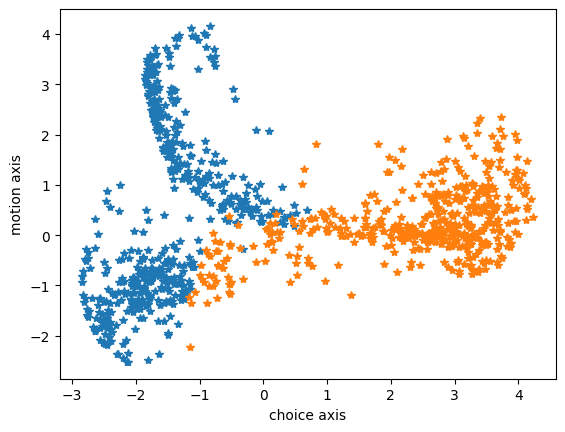

In [ ]:
#plot all fixed point for labels +/-1
plt.plot(proj_star_arr[y_ind0,0], proj_star_arr[y_ind0,1], "*")
plt.plot(proj_star_arr[y_ind1,0], proj_star_arr[y_ind1,1], "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")

Text(0, 0.5, 'motion axis')

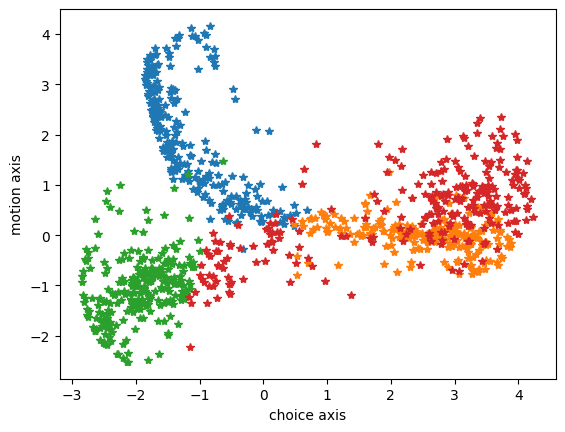

In [ ]:
#plot all fixed point for motion +/-1 and motion context
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,1], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,1], "*")

#plot all fixed point for color +/-1 and color context
ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,1], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,1], "*")

plt.xlabel("choice axis")
plt.ylabel("motion axis")

Text(0, 0.5, 'color axis')

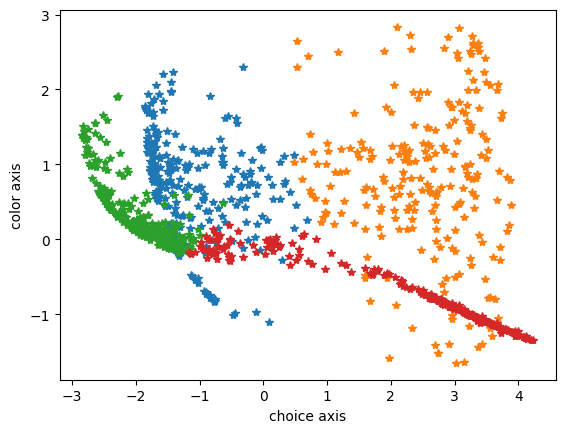

In [ ]:
#plot all fixed points as before, but on choice axis and color axis
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,2], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,2], "*")

ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,2], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,2], "*")

plt.xlabel("choice axis")
plt.ylabel("color axis")

.

**Section E: Infer stability at fixed points**

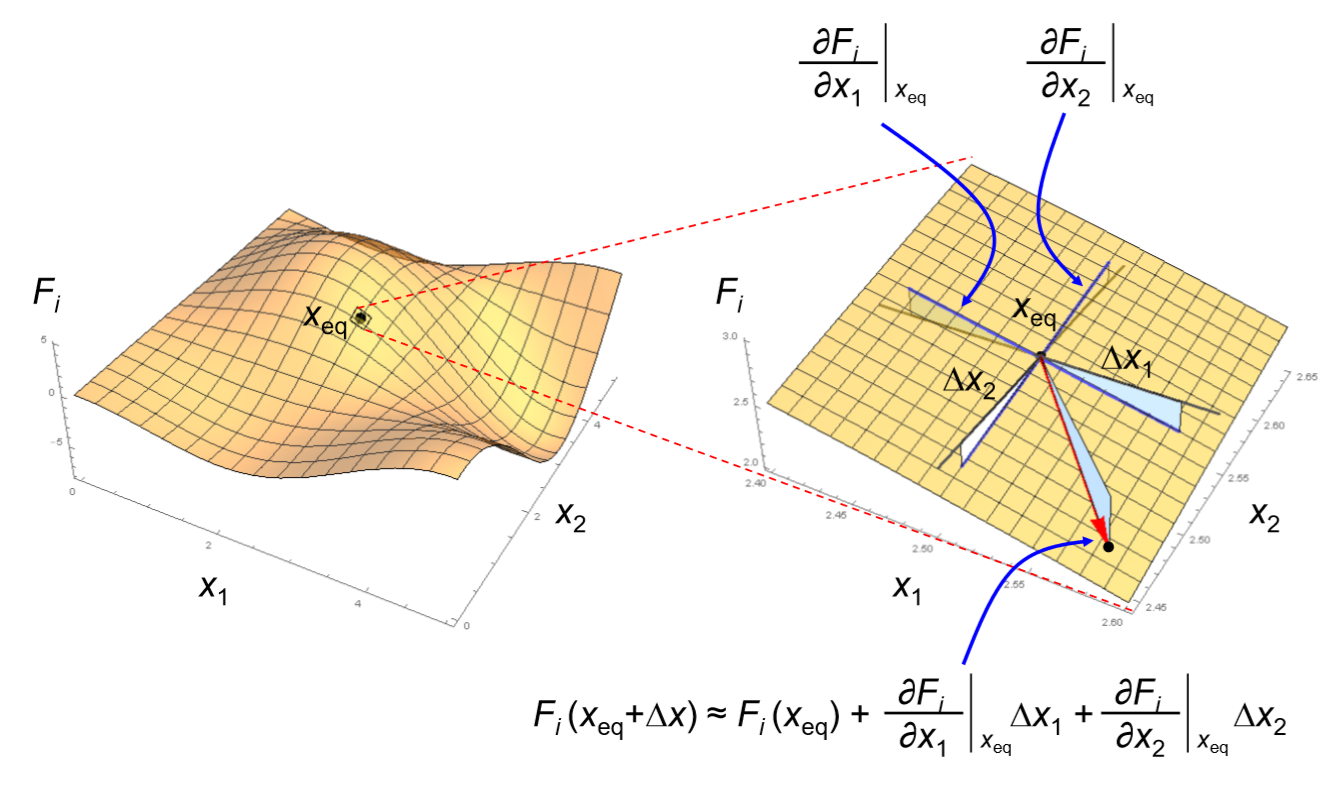

Figure from https://math.libretexts.org/Bookshelves/Scientific_Computing_Simulations_and_Modeling/Introduction_to_the_Modeling_and_Analysis_of_Complex_Systems_(Sayama)/05%3A_DiscreteTime_Models_II__Analysis/5.07%3A_5.7_Linear_Stability_Analysis_of_Discrete-Time_Nonlinear_Dynamical_Systems

In [ ]:
#linearize around a fixed point by computing the jacobian and its eigenvalues. Thus, detemrine stability using the evalues
def jacobian_and_eigs_at_fp(model, h_star, x_const=None, return_all=False, device='cpu'):
    """
    Linearize dynamics around fixed points
    Compute Jacobian of F(h) = -h + J tanh(h) + B x + b at h_star,
    and return eigenvalues and diagnostics.
    """

    # ensure on device and correct shape
    h = h_star.clone().detach().to(device).reshape(-1)
    N = h.numel()

    # ensure model matrices on same device & detach to numpy later
    J = model.J_weights.detach().to(device)       # shape [N, N]
    b = model.bias.detach().to(device).reshape(-1)   # shape [N,]

    # compute r* = tanh(h*)
    r = torch.tanh(h)

    # phi = 1 - r^2
    phi = (1.0 - r**2).reshape(-1)   # shape [N,]

    # build diag(phi) as a (N,N) tensor
    D = torch.diag(phi)   # (N,N)

    # Jacobian: -I + J @ D  (matches dF/dh_i_k = -delta_ik + J_ik * phi_k)
    I = torch.eye(N, device=device)
    Jc = -I + J @ D   # (N,N), continuous-time Jacobian

    # convert to numpy for eigendecomposition (move to cpu first)
    Jc_np = Jc.cpu().numpy()

    # eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eig(Jc_np)   # eigvals complex

    # discrete map eigenvalues for your update h_new = h + s * F(h)
    s = float(model.dt) / float(model.tau)
    M_np = np.eye(N) + s * Jc_np
    mu_vals, mu_vecs = np.linalg.eig(M_np)

    # diagnostics
    max_real = eigvals.real.max()
    spectral_radius = np.max(np.abs(eigvals))
    num_unstable_cont = (eigvals.real > 0).sum()          # eigenvalues with positive real part
    num_unstable_disc = (np.abs(mu_vals) > 1.0).sum()     # discrete update unstable modes

    report = {
        'N': N,
        's': s,
        'max_real_part_continuous': float(max_real),
        'spectral_radius_continuous': float(spectral_radius),
        'num_unstable_continuous': int(num_unstable_cont),
        'num_unstable_discrete': int(num_unstable_disc),
        'eigvals_continuous_sample': eigvals[:10],   # first few (for quick glance)
        'mu_vals_discrete_sample': mu_vals[:10],
    }

    if return_all:
        return Jc, eigvals, eigvecs, mu_vals, mu_vecs, report
    else:
        return eigvals, mu_vals, report

Iter 0, loss = 2.532e-01
Iter 100, loss = 2.342e-04
Iter 200, loss = 5.375e-06
Iter 300, loss = 3.349e-08
max real part (continuous): -0.04585748538374901
num unstable (continuous, Re>0): 0
num unstable (discrete, |mu|>1): 0


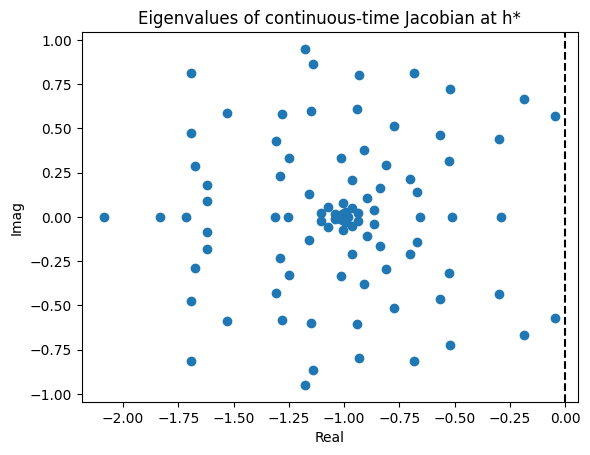

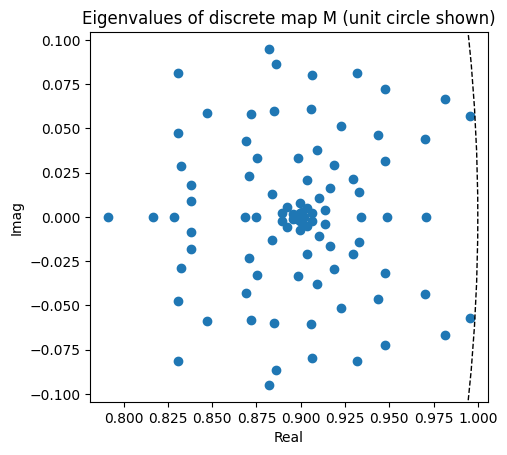

In [ ]:
trial = 0
h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X, all_h, model, trial, time_idx=int(0.7 * model.T))
x_const = X[trial,:,int(model.T*0.8)-10]

Jc, eigvals_cont, eigvecs_cont, eigvals_disc, eigvecs_disc, report = jacobian_and_eigs_at_fp(model, h_star, x_const=x_const, device='cpu', return_all=True)
print("max real part (continuous):", report['max_real_part_continuous'])
print("num unstable (continuous, Re>0):", report['num_unstable_continuous'])
print("num unstable (discrete, |mu|>1):", report['num_unstable_discrete'])

# to inspect eigenvalues more:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(eigvals_cont.real, eigvals_cont.imag)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Eigenvalues of continuous-time Jacobian at h*')

plt.figure()
plt.scatter(eigvals_disc.real, eigvals_disc.imag)
circle = plt.Circle((0,0), 1.0, color='k', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Eigenvalues of discrete map M (unit circle shown)')
plt.gca().set_aspect('equal', 'box')
plt.show()


In [ ]:
eigvals_real = eigvals_disc.real
print("Top 10 eigenvalues:", np.sort(eigvals_real)[::-1][:10])
#top evalues close to 1 => slow stable manifold in the direction of the eigenvector
#how does the eigenvector direction compare to the choice axis direction?

Top 10 eigenvalues: [0.99541425 0.99541425 0.98122146 0.98122146 0.97101386 0.97004733
 0.97004733 0.94874063 0.9478686  0.9478686 ]


In [ ]:
s = model.dt / model.tau

# 2) find slowest (least negative real part) lambda_F
eigvals_F = model.tau * eigvals_cont
eigvecs_F = eigvecs
idx = np.argmax(eigvals_F.real)   # index of maximum real part (closest to zero)
lambda_F = eigvals_F[idx]
mu = eigvals_disc[idx]

print("lambda_F (closest to zero):", lambda_F)
print("corresponding discrete mu (should equal 1 + s*lambda_F):", mu, "calc:", 1 + s*lambda_F)

# 3) continuous time eigenvalue and time constant
lambda_cont = lambda_F / model.tau
tau_decay_cont = -1.0 / lambda_cont.real
tau_decay_disc = -model.dt / np.log(mu.real)   # use real part if mu is real; if complex use abs(mu)
print("lambda_cont:", lambda_cont, "tau_decay (cont):", tau_decay_cont, "tau_decay (disc):", tau_decay_disc)

# 4) eigenvector alignment with choice axis and readout
# eigvecs_F from numpy eigvecs (shape N x N), get eigenvector:
v = eigvecs_F[:, idx]   # complex
v_real = np.real(v)     # principal direction (could also use magnitude)
# normalize
v_unit = v_real / (np.linalg.norm(v_real) + 1e-12)

# compute cosine with choice axis and readout
cos_choice = np.dot(v_unit, axes_orth[0,:]) / (np.linalg.norm(axes_orth[0,:])+1e-12)
cos_readout = np.dot(v_unit, model.fc_out.weight.reshape(-1).cpu().detach().numpy()) / (np.linalg.norm(model.fc_out.weight.reshape(-1).cpu().detach().numpy())+1e-12)
print("cosine with choice axis:", cos_choice, "cosine with readout:", cos_readout)

lambda_F (closest to zero): (-0.45857486+5.6866956j)
corresponding discrete mu (should equal 1 + s*lambda_F): (0.9812214576578699-0.0667592931859778j) calc: (0.9541425+0.56866956j)
lambda_cont: (-0.045857485+0.56866956j) tau_decay (cont): 21.80669 tau_decay (disc): 52.75068987801741
cosine with choice axis: -0.1422047221079775 cosine with readout: -0.13288173


/tmp/ipython-input-1091616205.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos_choice = np.dot(v_unit, axes_orth[0,:]) / (np.linalg.norm(axes_orth[0,:])+1e-12)


In [ ]:
# 1) get the eigenvector (real part)
idx_slow=3
v_h = np.real(eigvecs_F[:, idx_slow])
v_h = v_h / (np.linalg.norm(v_h) + 1e-12)

# 2) convert to r-space using phi = 1 - tanh(h_star)^2
h_np = h_star.detach().cpu().numpy().reshape(-1)
phi = 1.0 - np.tanh(h_np)**2   # shape (N,)
v_r = phi * v_h
v_r = v_r / (np.linalg.norm(v_r) + 1e-12)

# 3) normalize axes you're comparing
beta_choice_unit = axes_orth[0,:] / (np.linalg.norm(axes_orth[0,:]) + 1e-12)
w_out_unit = model.fc_out.weight.reshape(-1).cpu().detach().numpy() / (np.linalg.norm(model.fc_out.weight.cpu().detach().numpy()) + 1e-12)

# 4) cosine similarities
cos_choice = np.dot(v_r, beta_choice_unit)
cos_readout = np.dot(v_r, w_out_unit)

print("cosine (slow eig in r-space, choice axis) :", cos_choice)
print("cosine (slow eig in r-space, readout)      :", cos_readout)

# 5) optional: compare with centroid difference of +1 / -1 FPs in r-space
# fps_r should be r* values; if you have them:
if 'fps' in globals():
    cent_pos = fps[labels_fp==1].mean(0)
    cent_neg = fps[labels_fp==-1].mean(0)
    fp_diff = (cent_pos - cent_neg)
    fp_diff = fp_diff / (np.linalg.norm(fp_diff) + 1e-12)
    print("cosine (slow eig in r-space, fp_diff)      :", np.dot(v_r, fp_diff))

cosine (slow eig in r-space, choice axis) : -0.2559279070022889
cosine (slow eig in r-space, readout)      : -0.2813854


/tmp/ipython-input-3341636776.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos_choice = np.dot(v_r, beta_choice_unit)


In [ ]:
w_out = model.fc_out.weight.detach().cpu().numpy().reshape(-1)

# normalize
w_out = w_out / np.linalg.norm(w_out)

# regression-based choice axis, normalize
beta = axes_orth[0,:] / (np.linalg.norm(axes_orth[0,:]) + 1e-12)

# cosine between readout and your choice axis
print("cos(readout, choice axis):", np.dot(w_out, beta))

cos(readout, choice axis): 0.5322805708345383


/tmp/ipython-input-2337638249.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print("cos(readout, choice axis):", np.dot(w_out, beta))
